# Hall effect 

In [1]:
#======= librerie =============#

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
%matplotlib inline

print("\nLibrerie caricate correttamente\n")


Librerie caricate correttamente



In [2]:
#======== definizioni ==========#

# =========================================================
# 1. FUNZIONI DI CARICAMENTO (Gestiscono virgole o punti e virgola)
# =========================================================
def load_csv_data(filepath):

    df = pd.read_csv(filepath, sep= ";", decimal=',', header = None)
    
    # Assumiamo che la colonna 0 sia B (o T) e la colonna 1 sia rho o RH
    x = df.iloc[:, 0].values.astype(float)
    y = df.iloc[:, 1].values.astype(float)
    
    # Ordiniamo in base a B crescente (fondamentale per le interpolazioni)
    sort_idx = np.argsort(x)
    return x[sort_idx], y[sort_idx]

# =========================================================
# 2. FUNZIONI FISICHE (Conversioni e Calcoli)
# =========================================================
def get_MR(rho_array):
    """Calcola la Magnetoresistenza MR = (rho(B) - rho(0)) / rho(0)"""
    rho_0 = rho_array[0] # Prende il valore a campo più basso (idealmente B=0)
    return (rho_array - rho_0) / rho_0

def get_rho_xy(RH_array, B_array, factor=0.1):
    """
    Calcola rho_xy = R_H * B.
    Se R_H è in mm^3/C e B in Tesla, il fattore 0.1 restituisce muOhm*cm.
    """
    return RH_array * B_array * factor

# =========================================================
# 3. LA FUNZIONE "MASTER" (Estrapola e Allinea tutto)
# =========================================================
def process_hall_dataset(file_rho, file_RH):
    """
    Prende in pasto i percorsi dei file rho(B) e RH(B) per una data T.
    Allinea R_H sull'asse B di rho(B), e restituisce tutte le grandezze pronte per i fit.
    """
    # 1. Caricamento dati grezzi R_H
    df_RH = pd.read_csv(file_RH, sep=";", decimal=',', header=None)
    df_RH_clean = df_RH.groupby(0).mean().reset_index() # Ottima mossa per i duplicati!
    
    B_RH = df_RH_clean.iloc[:, 0].values.astype(float)
    RH_raw = df_RH_clean.iloc[:, 1].values.astype(float)
    
    # 2. Caricamento dati grezzi Rho
    df_rho = pd.read_csv(file_rho, sep=";", decimal=',', header=None)
    df_rho_clean = df_rho.groupby(0).mean().reset_index()
    
    B_rho = df_rho_clean.iloc[:, 0].values.astype(float)
    rho_xx = df_rho_clean.iloc[:, 1].values.astype(float) # <-- CORRETTO IL NOME QUI!
    
    if B_rho is None or B_RH is None:
        return None
    
    # 3. Interpolazione di R_H sui punti di campo magnetico B_rho
    RH_interp_func = interp1d(B_RH, RH_raw, kind='cubic', fill_value="extrapolate")
    RH_aligned = RH_interp_func(B_rho)
    
    # 4. Calcolo Grandezze Fisiche
    MR = get_MR(rho_xx)
    rho_xy = get_rho_xy(RH_aligned, B_rho, factor=0.1)
    
    # 5. Calcolo Cotangente dell'Angolo di Hall (cot(theta_H) = rho_xx / rho_xy)
    with np.errstate(divide='ignore', invalid='ignore'):
        cot_theta_H = rho_xx / rho_xy
        cot_theta_H[B_rho == 0] = np.nan 
        
    results = pd.DataFrame({
        'B_Tesla': B_rho,
        'rho_xx': rho_xx,          
        'MR_adim': MR,             
        'RH_aligned': RH_aligned,  
        'rho_xy': rho_xy,          
        'cot_theta_H': cot_theta_H 
    })
    
    return results

⚠️ Attenzione: File rho mancante per T = 1.5K. Lo salto.


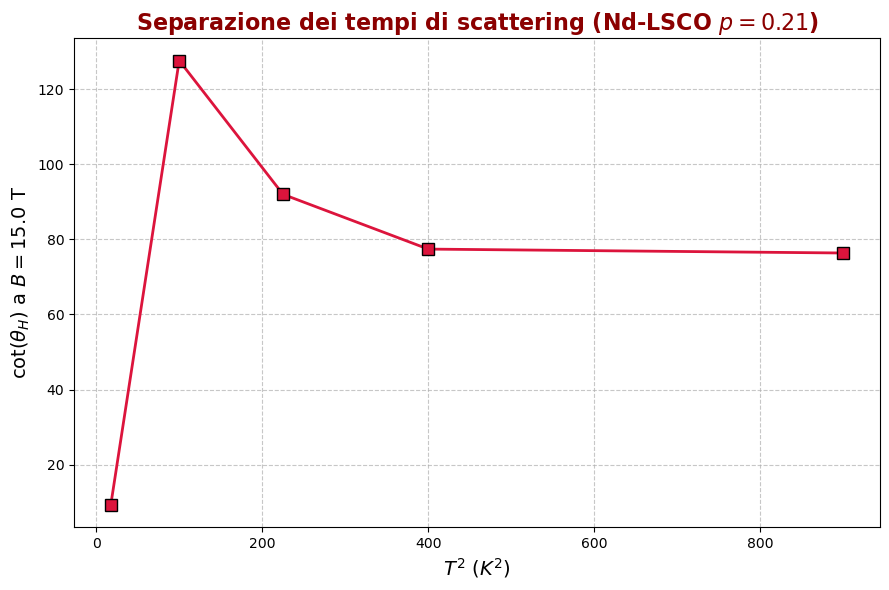

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os # <--- Ci serve per controllare se i file esistono!

# Lista delle temperature
T_list = [1.5, 4.2, 10, 15, 20, 30]

cot_theta_vs_T = []
T_validi = []

B_target = 15.0 

for T in T_list:
    file_rho = f"Data_sets/Nd-LSCO_p21/rho_Nd-LSCO_p21_{T:g}K.csv"
    file_RH  = f"Data_sets/Nd-LSCO_p21/RH(B)_Nd-LSCO_p21_{T:g}K.csv"
    
    # 🟢 PROTEZIONE: Controlliamo se ENTRAMBI i file esistono fisicamente
    if not os.path.exists(file_rho):
        print(f"⚠️ Attenzione: File rho mancante per T = {T}K. Lo salto.")
        continue
    if not os.path.exists(file_RH):
        print(f"⚠️ Attenzione: File RH mancante per T = {T}K. Lo salto.")
        continue
        
    # Se arriva qui, i file esistono e possiamo processarli in sicurezza
    df_T = process_hall_dataset(file_rho, file_RH)
    
    if df_T is not None and not df_T.empty:
        idx_B = (np.abs(df_T['B_Tesla'] - B_target)).argmin()
        cot_val = df_T['cot_theta_H'].iloc[idx_B]
        
        cot_theta_vs_T.append(cot_val)
        T_validi.append(T)

T_array = np.array(T_validi)
cot_array = np.array(cot_theta_vs_T)

# =========================================================
# IL PLOT DI ANDERSON: cot(theta_H) vs T^2
# =========================================================
if len(T_array) > 0:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(T_array**2, cot_array, 's-', color='crimson', markersize=8, markeredgecolor='black', linewidth=2)

    ax.set_xlabel(r"$T^2 \ (K^2)$", fontsize=14)
    ax.set_ylabel(f"$\cot(\\theta_H)$ a $B={B_target}$ T", fontsize=14)
    ax.set_title("Separazione dei tempi di scattering (Nd-LSCO $p=0.21$)", fontsize=16, fontweight='bold', color='darkred')
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Nessun dato valido trovato per fare il plot!")

Estraendo i dati a 15 T per p = 0.24...
 ⚠️ Salto T = 15K: file isotermico rho(B) non trovato.


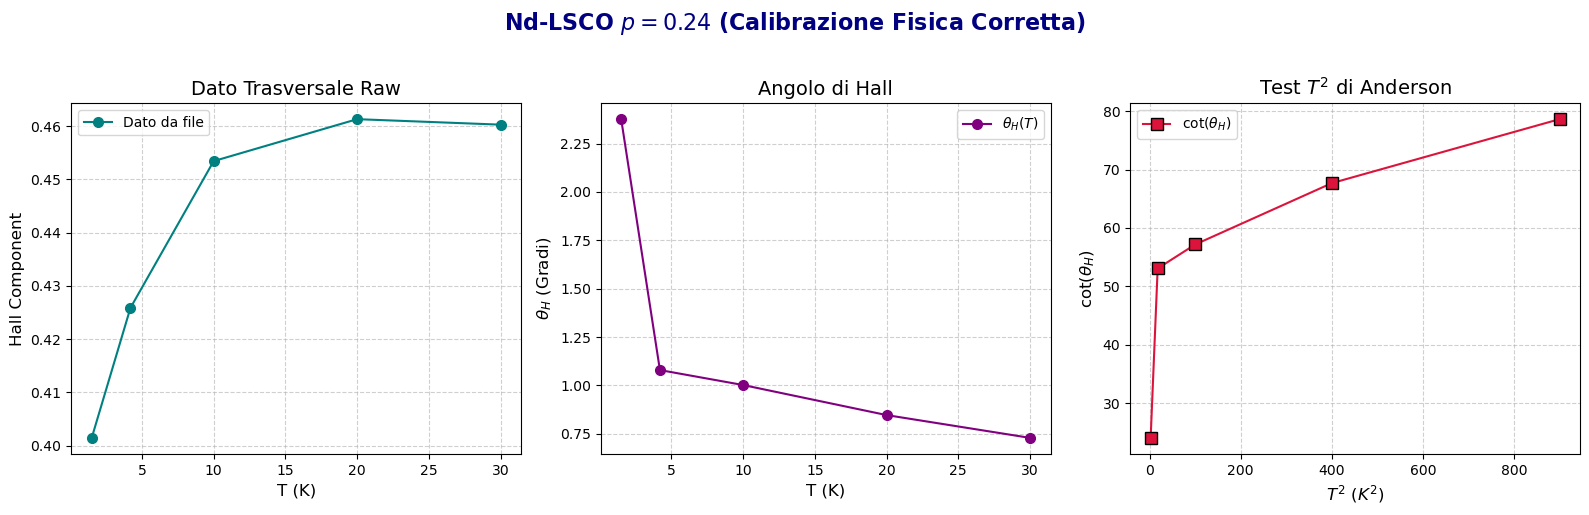

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
import os

# =================================================================
# 1. Caricamento globale di R_H(T)
# =================================================================
file_RH_024 = "Data_sets/Nd-LSCO_p24/RH_Nd-LSCO_p24.csv"

# Carichiamo R_H(T) e prepariamo una funzione per interpolare a qualsiasi T
df_RH = pd.read_csv(file_RH_024, sep=";", decimal=',', header=None)
df_RH_clean = df_RH.groupby(0).mean().reset_index()

T_RH_data = df_RH_clean.iloc[:, 0].values.astype(float)
RH_data = df_RH_clean.iloc[:, 1].values.astype(float)

# Interpolatore lineare: gli diamo una T, ci restituisce R_H
RH_interp = interp1d(T_RH_data, RH_data, kind='linear', fill_value="extrapolate")

# =================================================================
# 2. Estrazione iterativa di rho_xx a 15 Tesla
# =================================================================
T_list = [1.5, 4.2, 10, 15, 20, 30]
B_target = 15.0

T_validi = []
rho_15T_list = []
RH_val_list = []

print("Estraendo i dati a 15 T per p = 0.24...")
for T in T_list:
    file_rho = f"Data_sets/Nd-LSCO_p24/rho_Nd-LSCO_p24_{T:g}K.csv"
    
    if not os.path.exists(file_rho):
        print(f" ⚠️ Salto T = {T}K: file isotermico rho(B) non trovato.")
        continue
        
    # Carichiamo la rho(B) per questa temperatura
    df_rho = pd.read_csv(file_rho, sep=";", decimal=',', header=None)
    df_rho_clean = df_rho.groupby(0).mean().reset_index()
    B_rho = df_rho_clean.iloc[:, 0].values.astype(float)
    rho_xx = df_rho_clean.iloc[:, 1].values.astype(float)
    
    # Estraiamo la resistività al campo più vicino a 15 T
    idx_B = (np.abs(B_rho - B_target)).argmin()
    rho_val = rho_xx[idx_B]
    
    # Valutiamo R_H esattamente a questa temperatura
    RH_val = RH_interp(T)
    
    T_validi.append(T)
    rho_15T_list.append(rho_val)
    RH_val_list.append(RH_val)

# Convertiamo tutto in comodi array NumPy
T_024 = np.array(T_validi)
rho_xx_024 = np.array(rho_15T_list)
RH_024 = np.array(RH_val_list)

# =================================================================
# 3. Calcolo Grandezze Fisiche (CORRETTO)
# =================================================================
# Se il file CSV contiene già la componente trasversale corretta,
# non dobbiamo moltiplicarla per B_target. Usiamo direttamente il valore del file!
rho_xy_024 = RH_024  

with np.errstate(divide='ignore', invalid='ignore'):
    # Calcolo pulito della cotangente
    cot_theta_024 = rho_xx_024 / rho_xy_024
    
    # Angolo di Hall in gradi
    theta_H_rad = np.arctan(rho_xy_024 / rho_xx_024)
    theta_H_deg = np.degrees(theta_H_rad)

# =================================================================
# 4. IL PLOT REALE
# =================================================================
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Nd-LSCO $p=0.24$ (Calibrazione Fisica Corretta)", fontsize=16, fontweight='bold', color='navy', y=1.02)

# Plot 1: Asse Y del file
axs[0].plot(T_024, RH_024, 'o-', color='teal', markersize=7, label='Dato da file')
axs[0].set_xlabel('T (K)', fontsize=12)
axs[0].set_ylabel('Hall Component', fontsize=12)
axs[0].set_title('Dato Trasversale Raw', fontsize=14)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# Plot 2: Theta_H(T)
axs[1].plot(T_024, theta_H_deg, 'o-', color='purple', markersize=7, label='$\\theta_H(T)$')
axs[1].set_xlabel('T (K)', fontsize=12)
axs[1].set_ylabel('$\\theta_H$ (Gradi)', fontsize=12)
axs[1].set_title('Angolo di Hall', fontsize=14)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend()

# Plot 3: cot(Theta_H) vs T^2 (Il Test di Anderson)
axs[2].plot(T_024**2, cot_theta_024, 's-', color='crimson', markersize=8, markeredgecolor='black', label='$\\cot(\\theta_H)$')
axs[2].set_xlabel('$T^2 \ (K^2)$', fontsize=12)
axs[2].set_ylabel('$\\cot(\\theta_H)$', fontsize=12)
axs[2].set_title('Test $T^2$ di Anderson', fontsize=14)
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend()

plt.tight_layout()
plt.show()